# Appendix A: WMH-SynthSeg on Colab

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Zane-133/new-jupyterbook/blob/main/appendix_wmh_colab.ipynb)

The script that computes the WMH-SynthSeg label maps read by Chapter 04. It does not run as part
of the book (it needs a GPU, see Chapter 04); open it in Colab with the button above.

Before you start: upload `neurodesk_upload.zip` (`old/`, `new/`, `freesurfer/`) to the root of
My Drive, and choose Runtime → Change runtime type → **A100 GPU** (a T4 runs out of memory).
Every label map is saved to Drive as soon as it is computed; after a disconnect, run all cells
again and finished scans are skipped.

At the end the results are zipped to `My Drive/lfbook/WMH_SynthSeg_old.zip`. On Neurodesk,
upload the zip to the home folder and unzip it into the results folder:

```bash
unzip -n ~/WMH_SynthSeg_old.zip -d ~/neurodesktop-storage/lfbook/results
```

## Settings

In [2]:
import os, re, shutil, subprocess, sys, time
from collections import deque
from pathlib import Path

import pandas as pd

ZIP       = Path('/content/drive/MyDrive/neurodesk_upload.zip')   # input data on Drive
DATA      = Path('/content/neurodesk_upload')                     # unzipped on the Colab disk
EXPORT    = Path('/content/drive/MyDrive/lfbook/wmh_export')      # results on Drive (zip root)
WMH       = EXPORT / 'old' / 'seg' / 'WMH_SynthSeg'                # same layout as the book
ZIP_OUT   = Path('/content/drive/MyDrive/lfbook/WMH_SynthSeg_old.zip')
WORK      = Path('/content/work')                                 # staging folders
WMH_REPO  = Path('/content/wmh')                                  # WMH-SynthSeg code
COMMIT    = '2bf9a42'
WMH_MODEL = Path('/content/drive/MyDrive/wmh_model/WMH-SynthSeg_v10_231110.pth')  # kept on Drive
INF       = WMH_REPO / 'WMHSynthSeg' / 'inference.py'


def sh(cmd, log=None, cwd=None):
    """Run a bash command, print its output and append it to `log`. Stop on failure."""
    if log:
        Path(log).parent.mkdir(parents=True, exist_ok=True)
    fh = open(log, 'a') if log else None
    p = subprocess.Popen(['bash', '-lc', cmd], cwd=cwd, stdout=subprocess.PIPE,
                         stderr=subprocess.STDOUT, text=True, bufsize=1)
    for line in p.stdout:
        print(line, end='')
        if fh:
            fh.write(line)
    p.wait()
    if fh:
        fh.close()
    if p.returncode:
        raise RuntimeError(f'exit code {p.returncode}: {cmd}')

## Drive, GPU and data

In [3]:
from google.colab import drive
drive.mount('/content/drive')
assert ZIP.exists(), f'upload neurodesk_upload.zip to {ZIP.parent}'

import torch
assert torch.cuda.is_available(), 'no GPU: Runtime -> Change runtime type -> A100 GPU'
print('torch', torch.__version__, '|', torch.cuda.get_device_name(0))

if not DATA.exists():
    sh(f'unzip -q {ZIP} -d {DATA.parent}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
torch 2.11.0+cu130 | NVIDIA A100-SXM4-40GB


## WMH-SynthSeg

Code from commit `2bf9a42`. Two patches: the model path (hard-coded to `/app/models`) points to
the Drive folder, and `weights_only=False` for PyTorch ≥ 2.6. The model weights (790 MB) are
downloaded once and kept on Drive.

In [4]:
sh(f'{sys.executable} -m pip install -q nibabel')
if not WMH_REPO.exists():
    sh(f'git clone -q https://github.com/lasopablo/freesurfer-freesurfer-dev-mri_WMHsynthseg.git {WMH_REPO} '
       f'&& git -C {WMH_REPO} checkout -q {COMMIT}')
    sh(f"""sed -i "s#'/app/models'#'{WMH_MODEL.parent}'#" {INF}""")
    sh(f'sed -i "s/torch.load(model_file, map_location=device)/'
       f'torch.load(model_file, map_location=device, weights_only=False)/" {INF}')
if not (WMH_MODEL.exists() and WMH_MODEL.stat().st_size > 0):
    WMH_MODEL.parent.mkdir(parents=True, exist_ok=True)
    sh(f'wget -q -c -O {WMH_MODEL} https://ftp.nmr.mgh.harvard.edu/pub/dist/lcnpublic/dist/WMH-SynthSeg/{WMH_MODEL.name}')
sh(f"grep -n 'model_file = \\|torch.load(' {INF}")

94:    model_file = os.path.join('/content/drive/MyDrive/wmh_model', 'WMH-SynthSeg_v10_231110.pth')
127:        checkpoint = torch.load(model_file, map_location=device, weights_only=False)


## Scan table

Same as Chapter 02: 3T `<sub>_acq-{highres,lowres}_<mod>`, 64mT `<sub>_<ses>_run-N_<mod>`,
localizers left out; 66 + 61 = 127 scans.

In [5]:
rows = []
for f in sorted((DATA / 'old').glob('3T/sub-*/anat/*.nii.gz')):
    m = re.fullmatch(r'(sub-\d+)_acq-(highres|lowres)_(T1w|T2w|FLAIR)\.nii\.gz', f.name)
    if m:
        sub, acq, mod = m.groups()
        rows.append(dict(scan=f.name[:-7], fs='3T', sub=sub, ses='n/a', acq=acq, run='-', mod=mod, src=str(f)))
for f in sorted((DATA / 'old').glob('64mT/sub-*/ses-*/anat/*.nii.gz')):
    m = re.fullmatch(r'(sub-\d+)_(ses-\d+)_(run-\d+)_(T1w|T2w|FLAIR)\.nii\.gz', f.name)
    if m:
        sub, ses, run, mod = m.groups()
        rows.append(dict(scan=f.name[:-7], fs='64mT', sub=sub, ses=ses, acq='-', run=run, mod=mod, src=str(f)))
scans = pd.DataFrame(rows)
n = scans.fs.value_counts()
assert (n['3T'], n['64mT']) == (66, 61) and scans.scan.is_unique, f'scan count does not match: {dict(n)}'


def seg_path(r):
    """<WMH>/<fs>/<sub>/[<ses>/]<scan>_WMHseg.nii.gz, as seg_path() in the book's common.py"""
    d = WMH / r['fs'] / r['sub']
    if r['ses'].startswith('ses-'):
        d = d / r['ses']
    return d / f"{r['scan']}_WMHseg.nii.gz"

## Resampling to 1 mm

Before the network sees a scan, `inference.py` does four things:

1. reorders the axes to R, A, S (only swaps and flips, no interpolation);
2. divides the image by its maximum;
3. resamples it to 1 mm with `myzoom_torch` (in `utils.py`);
4. pads it with zeros to a multiple of 32.

`myzoom_torch` works per axis with `factor = voxel size / 1 mm`: the new grid has
`round(size × factor)` voxels, and each new voxel is a linear interpolation between the two
nearest original voxels (trilinear over the three axes). There is no smoothing before it.

The label map and the volumes are written on this 1 mm grid, not on the grid of the input scan.

The table lists the voxel size and grid of every scan in R × A × S order, as `inference.py` sees
them, with the 1 mm grid and the padded grid the network runs on.

In [12]:
import nibabel as nib
import numpy as np


def grid_ras(src):
    """Voxel size (mm) and grid size in R, A, S order, as inference.py sees them (header only)."""
    img = nib.load(src)
    axis = nib.io_orientation(img.affine)[:, 0].astype(int)   # input axis i -> RAS axis axis[i]
    vox, shape = np.zeros(3), np.zeros(3, int)
    vox[axis], shape[axis] = img.header.get_zooms()[:3], img.shape[:3]
    return vox, shape


rows = []
for r in scans.to_dict('records'):
    vox, shape = grid_ras(r['src'])
    new = np.round(shape * vox).astype(int)                    # factor = voxel size / 1 mm
    pad = (np.ceil(new / 32) * 32).astype(int)
    rows.append(dict(fs=r['fs'], acq=r['acq'], mod=r['mod'],
                     voxel_mm=' × '.join(f'{x:.2f}' for x in vox),
                     grid=' × '.join(map(str, shape)),
                     grid_1mm=' × '.join(map(str, new)),
                     padded=' × '.join(map(str, pad))))
grids = (pd.DataFrame(rows).groupby(list(rows[0]), sort=False).size().rename('scans')
         .reset_index().sort_values(['fs', 'acq', 'mod'], ignore_index=True))
grids

,fs,acq,mod,voxel_mm,grid,grid_1mm,padded,scans
0,3T,highres,FLAIR,0.43 × 0.43 × 5.50,512 × 512 × 27,220 × 220 × 148,224 × 224 × 160,11
1,3T,highres,T1w,0.90 × 0.49 × 0.49,150 × 448 × 448,135 × 220 × 220,160 × 224 × 224,1
2,3T,highres,T1w,0.49 × 0.49 × 1.00,448 × 448 × 156,220 × 220 × 156,224 × 224 × 160,10
3,3T,highres,T2w,0.22 × 0.22 × 3.00,1008 × 1008 × 50,220 × 220 × 150,224 × 224 × 160,11
4,3T,lowres,FLAIR,1.38 × 1.38 × 5.50,160 × 160 × 28,220 × 220 × 154,224 × 224 × 160,11
5,3T,lowres,T1w,1.38 × 1.38 × 5.00,160 × 160 × 31,220 × 220 × 155,224 × 224 × 160,11
6,3T,lowres,T2w,1.38 × 1.38 × 5.00,160 × 160 × 31,220 × 220 × 155,224 × 224 × 160,11
7,64mT,-,FLAIR,1.70 × 1.70 × 5.00,106 × 130 × 40,180 × 221 × 200,192 × 224 × 224,19
8,64mT,-,FLAIR,1.70 × 1.70 × 5.00,106 × 130 × 30,180 × 221 × 150,192 × 224 × 160,1
9,64mT,-,FLAIR,0.85 × 0.85 × 5.00,212 × 260 × 40,180 × 221 × 200,192 × 224 × 224,1


Two things change the image:

- **Thick slices.** Almost every scan has 3–5.5 mm slices. Resampling fills the gap with 2–4
  new slices that are only blends of the two real ones; no detail is added.
- **Fine in-plane voxels.** 3T highres scans (0.22–0.49 mm) are shrunk 2–4.5 times. Linear
  interpolation uses only the two nearest voxels and skips the ones in between, so fine detail
  is lost and edges become jagged.

64mT scans (1.6–1.7 mm in-plane) are slightly enlarged in-plane: smoother, but no new detail.

### Examples

Five scans of `sub-0011`: two HF (3T highres T2w, FLAIR) and three LF (64mT T1w, T2w, FLAIR),
before and after the resampling above. Each panel shows the whole head (220 mm window), with
every voxel drawn as a block of its real size. Left: axial; right: coronal, where the slice
thickness shows.

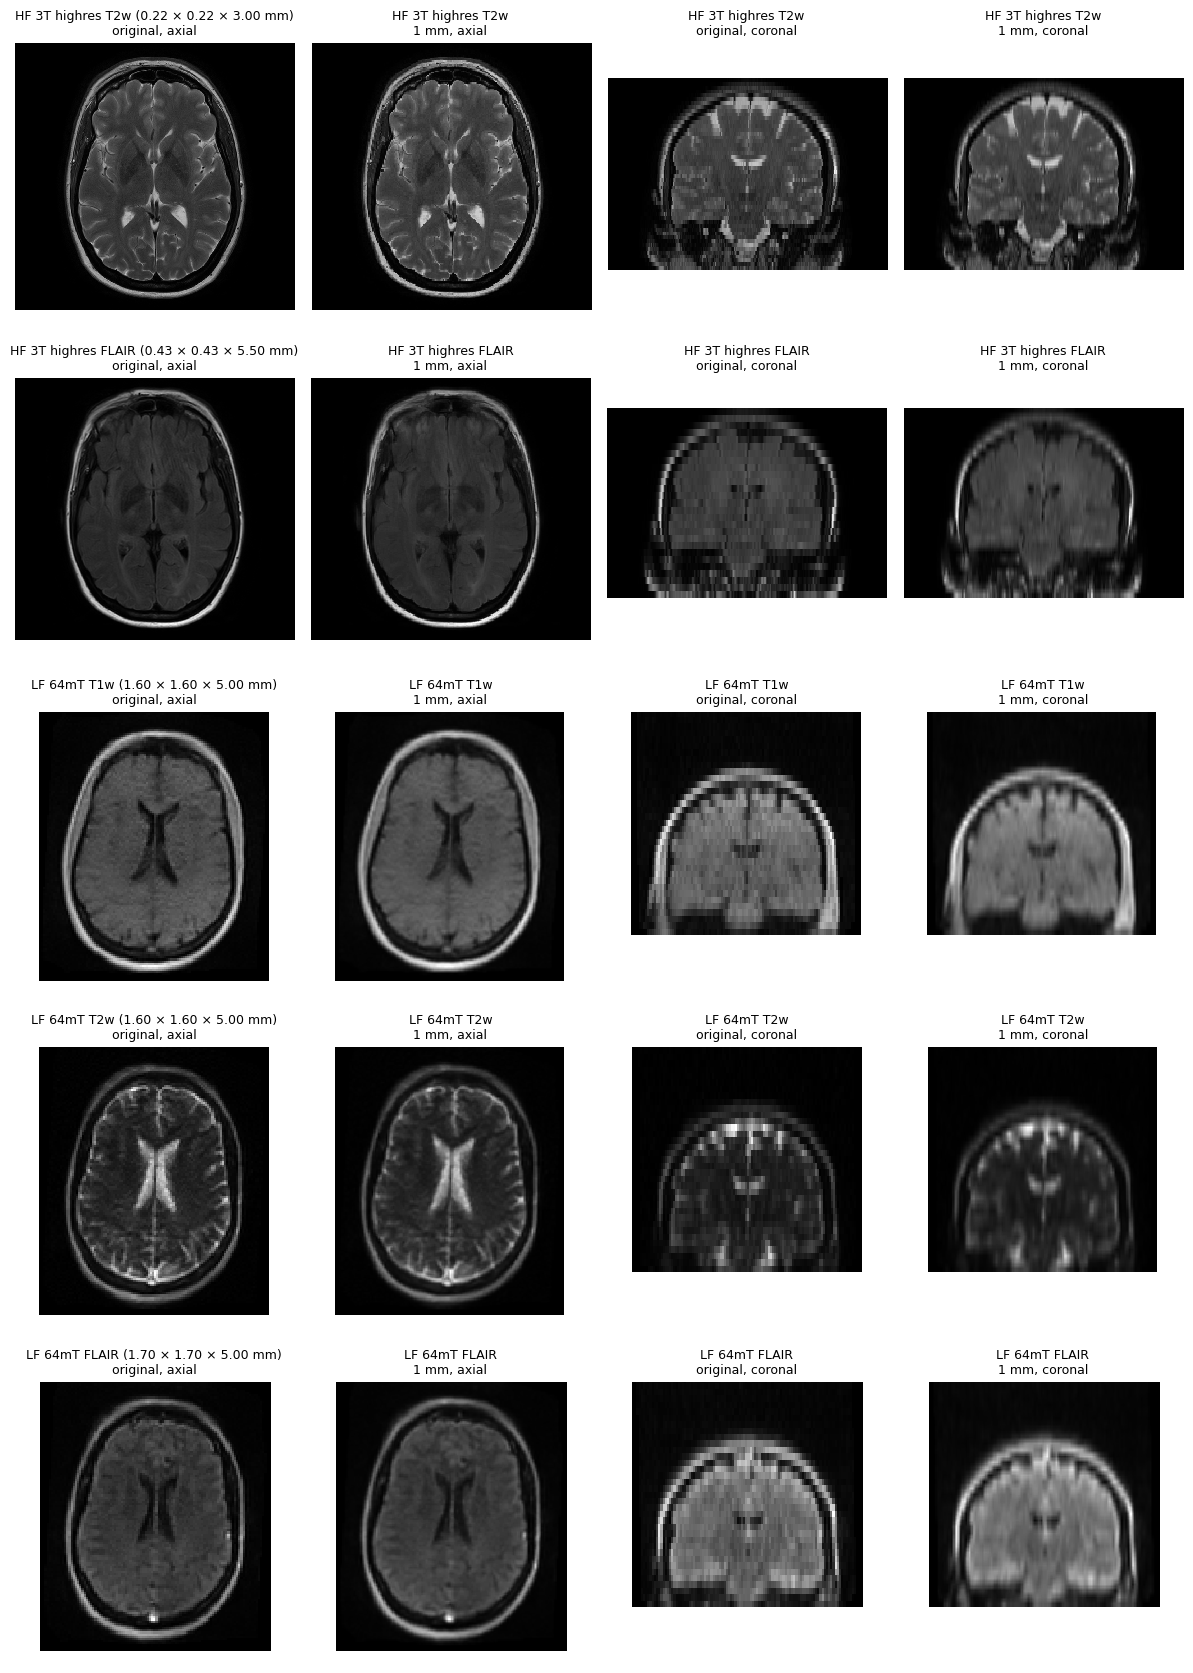

In [15]:
import matplotlib.pyplot as plt
import torch

sys.path.insert(0, str(INF.parent))
from utils import MRIread, align_volume_to_ref, myzoom_torch


def to_1mm(src):
    """The first steps of inference.py: reorient to RAS, scale to [0, 1], resample to 1 mm."""
    image, aff = MRIread(src)
    x = torch.tensor(np.squeeze(image).astype(float))
    x, aff2 = align_volume_to_ref(x, aff, aff_ref=np.eye(4), return_aff=True, n_dims=3)
    x = x / torch.max(x)
    factors = np.sqrt(np.sum(aff2 ** 2, axis=0))[:-1]          # voxel size / 1 mm
    return x.numpy(), myzoom_torch(x, factors, device='cpu').numpy(), factors


def show(ax, img, vox, start, centre, title, half=110):
    """220 mm window around `centre`; each voxel is drawn as a block of its real size.
    Positions in mm along the original grid; `start` = position of the first voxel."""
    lo = np.array(start) - 0.5 * np.array(vox)
    ax.imshow(img.T, cmap='gray', origin='lower', interpolation='nearest', vmin=0, vmax=img.max(),
              extent=(lo[0], lo[0] + img.shape[0] * vox[0], lo[1], lo[1] + img.shape[1] * vox[1]))
    ax.set_xlim(centre[0] - half, centre[0] + half)
    ax.set_ylim(centre[1] - half, centre[1] + half)
    ax.set_title(title, fontsize=9)
    ax.axis('off')


EXAMPLES = ['sub-0011_acq-highres_T2w', 'sub-0011_acq-highres_FLAIR',                        # HF
            'sub-0011_ses-01_run-1_T1w', 'sub-0011_ses-01_run-1_T2w', 'sub-0011_ses-01_run-1_FLAIR']  # LF
fig, axes = plt.subplots(len(EXAMPLES), 4, figsize=(12, 3.4 * len(EXAMPLES)))
for ax, scan in zip(axes, EXAMPLES):
    r = scans.set_index('scan').loc[scan]
    name = f"HF 3T {r['acq']} {r['mod']}" if r['fs'] == '3T' else f"LF 64mT {r['mod']}"
    orig, new, f = to_1mm(r['src'])
    c = np.array([np.average(np.arange(n), weights=new.sum(axis=tuple(a for a in range(3) if a != d)))
                  for d, n in enumerate(new.shape)])                # brain centre (intensity), 1 mm grid
    i, j, k = np.round(c).astype(int)
    s0 = 0.5 - 0.5 * f                                            # first 1 mm voxel, in mm (myzoom_torch)
    c = c + s0
    ko, jo = np.round((np.array([k, j]) + 0.5) / f[[2, 1]] - 0.5).astype(int)   # nearest original slice
    vox = ' × '.join(f'{v:.2f}' for v in f)
    show(ax[0], orig[:, :, ko], f[[0, 1]], [0, 0], c[[0, 1]], f'{name} ({vox} mm)\noriginal, axial')
    show(ax[1], new[:, :, k], [1, 1], s0[[0, 1]], c[[0, 1]], f'{name}\n1 mm, axial')
    show(ax[2], orig[:, jo, :], f[[0, 2]], [0, 0], c[[0, 2]], f'{name}\noriginal, coronal')
    show(ax[3], new[:, j, :], [1, 1], s0[[0, 2]], c[[0, 2]], f'{name}\n1 mm, coronal')
fig.tight_layout()

## Segment and save

Scans without a label map on Drive are linked into one staging folder, and `inference.py` runs
once on it, so the model loads once. Label maps are moved to Drive and their volumes added to
`volumes_main.csv`. `inference.py` does not stop when a scan fails; those messages are shown if
any scan is left without a label map.

In [6]:
LOG = WMH / 'logs' / 'main.log'
todo = [r for r in scans.to_dict('records') if not seg_path(r).exists()]
if todo:
    stage, segout = WORK / 'stage', WORK / 'segout'
    for d in (stage, segout):
        shutil.rmtree(d, ignore_errors=True)
        d.mkdir(parents=True)
    for r in todo:
        os.symlink(r['src'], stage / f"{r['scan']}.nii.gz")

    # expandable_segments reduces GPU memory fragmentation
    sh(f'PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True {sys.executable} inference.py '
       f'--i {stage} --o {segout} --csv_vols {segout}/vols.csv --device cuda',
       cwd=INF.parent, log=LOG)

    for r in todo:
        seg = segout / f"{r['scan']}_seg.nii.gz"
        if seg.exists():
            seg_path(r).parent.mkdir(parents=True, exist_ok=True)
            shutil.move(seg, seg_path(r))

    # volume table: scan-table columns + volumes, merged with earlier results
    vols = pd.read_csv(segout / 'vols.csv')
    vols['scan'] = vols.pop('Input-file').map(lambda p: os.path.basename(p)[:-len('_seg.nii.gz')])
    tidy = pd.DataFrame(todo).drop(columns='src').merge(vols, on='scan')
    dst = WMH / 'volumes_main.csv'
    if dst.exists():
        tidy = pd.concat([pd.read_csv(dst, keep_default_na=False), tidy],
                         ignore_index=True).drop_duplicates('scan', keep='last')
    tidy.sort_values(['fs', 'sub', 'mod', 'acq']).to_csv(dst, index=False)

missing = [r['scan'] for r in scans.to_dict('records') if not seg_path(r).exists()]
if missing:
    sh(f"grep 'error occurred' {LOG} | sort | uniq -c || true")
    raise RuntimeError(f'{len(missing)} scans not segmented: {missing}')
print(f'WMH-SynthSeg: {len(scans)} scans done')

Arguments seem correct; loading Python packages...
Using cuda
Using 1 thread(s)
Preparing model and loading weights
Working on image 1 of 127: /content/work/stage/sub-0025_ses-02_run-1_T1w.nii.gz
     Loading input volume and normalizing to [0,1]
     Upscaling to target resolution
     Pushing data through the CNN
     Writing segmentation to disk: /content/work/segout/sub-0025_ses-02_run-1_T1w_seg.nii.gz
 
Working on image 2 of 127: /content/work/stage/sub-0025_acq-highres_T1w.nii.gz
     Loading input volume and normalizing to [0,1]
     Upscaling to target resolution
     Pushing data through the CNN
     Writing segmentation to disk: /content/work/segout/sub-0025_acq-highres_T1w_seg.nii.gz
 
Working on image 3 of 127: /content/work/stage/sub-0046_acq-lowres_T1w.nii.gz
     Loading input volume and normalizing to [0,1]
     Upscaling to target resolution
     Pushing data through the CNN
     Writing segmentation to disk: /content/work/segout/sub-0046_acq-lowres_T1w_seg.nii.gz
 
Wo

## Outputs

All outputs are saved to `My Drive/lfbook/wmh_export/old/seg/WMH_SynthSeg/`, except the zip.

| Output | File | Content | Made in step |
|---|---|---|---|
| Label maps | `{3T,64mT}/<sub>/[<ses>/]<scan>_WMHseg.nii.gz` | One per scan (127). Each voxel holds a label number, e.g. 77 = WMH, 2 = left white matter. | Segment and save |
| Volume table | `volumes_main.csv` | One row per scan: scan info, intracranial volume, and the volume of 33 labels in mm³. | Segment and save |
| Log | `logs/main.log` | Everything `inference.py` printed; used to find scans that failed. | Segment and save |
| Provenance | `PROVENANCE.txt` | GPU, PyTorch version, code commit, model file, settings. | Provenance and zip |
| Zip | `My Drive/lfbook/WMH_SynthSeg_old.zip` | All of the above, packed for Neurodesk. | Provenance and zip |

Not produced: QC scores (WMH-SynthSeg has no QC option, unlike SynthSeg)

## Provenance and zip

the calculation results will be sorted out and delivered to neurodesk for further registration and DICE calculation.

In [7]:
commit = subprocess.run(['git', '-C', str(WMH_REPO), 'log', '-1', '--format=%h %ad'],
                        capture_output=True, text=True).stdout.strip()
(WMH / 'PROVENANCE.txt').write_text(f"""WMH-SynthSeg results, old dataset ({len(scans)} scans)
Computed on Google Colab, Appendix A of the book; written {time.strftime('%Y-%m-%d %H:%M %Z')}
GPU: {torch.cuda.get_device_name(0)} | torch {torch.__version__}
Code: lasopablo/freesurfer-freesurfer-dev-mri_WMHsynthseg, commit {commit}
Model: {WMH_MODEL.name} ({WMH_MODEL.stat().st_size / 1e6:.0f} MB)
Settings: --device cuda, no --crop
""")
print((WMH / 'PROVENANCE.txt').read_text())

ZIP_OUT.unlink(missing_ok=True)
sh(f'zip -q -r {ZIP_OUT} old', cwd=EXPORT)
print(f'{ZIP_OUT}: {ZIP_OUT.stat().st_size / 1e6:.0f} MB')

WMH-SynthSeg results, old dataset (127 scans)
Computed on Google Colab, Appendix A of the book; written 2026-10-08 21:14 UTC
GPU: NVIDIA A100-SXM4-40GB | torch 2.11.0+cu130
Code: lasopablo/freesurfer-freesurfer-dev-mri_WMHsynthseg, commit 2bf9a42 Sat Jun 1 15:28:41 2024 -0400
Model: WMH-SynthSeg_v10_231110.pth (791 MB)
Settings: --device cuda, no --crop

/content/drive/MyDrive/lfbook/WMH_SynthSeg_old.zip: 74 MB
